In [ ]:
# 🎧 Audio Preprocessing Exploration  
## Data Pipeline for VoiceBank+DEMAND

This notebook demonstrates the `AudioPreprocessor` class and the preprocess.py pipeline. We transform raw waveforms into standardized log-magnitude spectrograms stored in a compressed `.npz` format to feed our models.

---

# ⚙️ 1. Configuration & Initialization

We initialize our preprocessor with parameters optimized for a U-Net architecture. 
Note the `fixed_shape=(256, 257)` which ensures our spectrograms are perfectly sized for neural network downsampling.

In [11]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import soundfile as sf
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.preprocess import AudioPreprocessor

# Initialize AudioPreprocessor class
preprocessor = AudioPreprocessor(
    sr=16000,
    n_fft=512,
    hop_length=128,
    fixed_shape=(256, 257),
    chunk_duration=2.0,
    chunk_overlap=0.0
)

In [ ]:
# 🛠️ 2. Signal Cleaning: DC Offset & RMS Normalization

Before computing the spectrogram, two essential preprocessing steps are applied:

- **remove_dc_offset** → recenters the waveform around 0.0 to eliminate constant bias  
- **rms_normalize** → scales the signal so its Root Mean Square (RMS) energy equals 1.0, ensuring consistent loudness across recordings

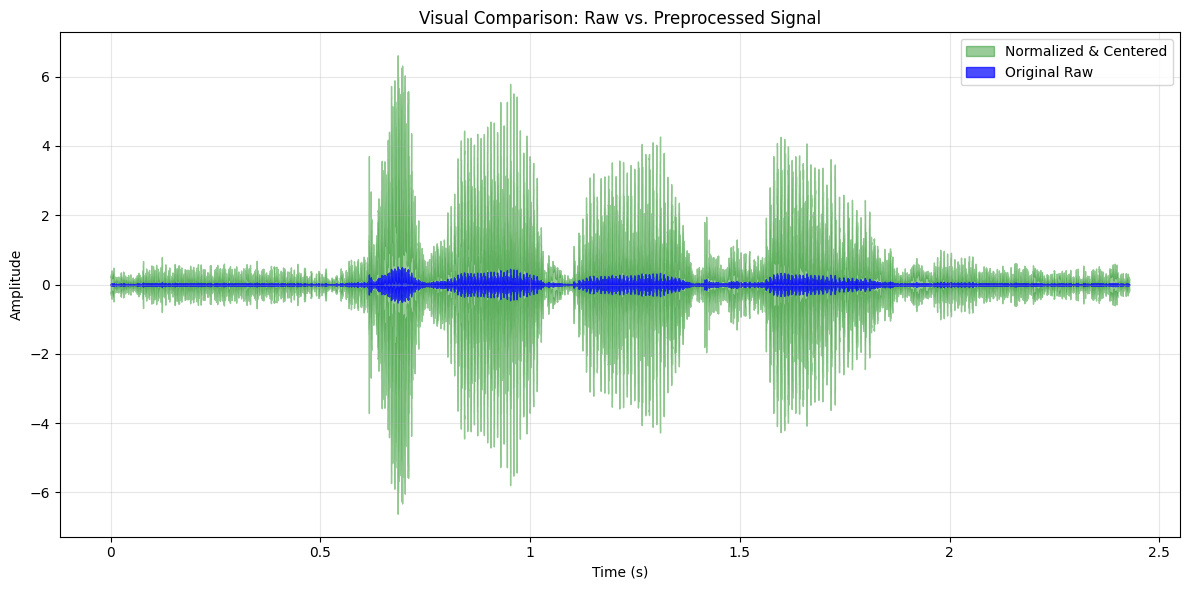

Original Mean (DC): 0.000009 -> New Mean: -0.000000
Original RMS (Volume): 0.078200 -> New RMS: 1.000000


In [16]:
# Load an example file
y_raw, _ = librosa.load(
    "../data/raw/wavs/train/noisy/00136.wav",
    sr=16000
)

# Step 1: Remove DC offset
y_dc = preprocessor.remove_dc_offset(y_raw)

# Step 2: RMS normalization
y_norm = preprocessor.rms_normalize(y_dc)

# Create a single plot for overlay
plt.figure(figsize=(12, 6))

# Plot the Normalized signal in the background
librosa.display.waveshow(y_norm, sr=preprocessor.sr, color='green', alpha=0.4, label='Normalized & Centered')

# Plot the Raw signal on top in a bolder color
librosa.display.waveshow(y_raw, sr=preprocessor.sr, color='blue', alpha=0.7, label='Original Raw')

plt.title("Visual Comparison: Raw vs. Preprocessed Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics to confirm the math
print(f"Original Mean (DC): {np.mean(y_raw):.6f} -> New Mean: {np.mean(y_norm):.6f}")
print(f"Original RMS (Volume): {np.sqrt(np.mean(y_raw**2)):.6f} -> New RMS: {np.sqrt(np.mean(y_norm**2)):.6f}")

In [17]:
from IPython.display import Audio, display

print("--- Original Raw Audio ---")
display(Audio(y_raw, rate=preprocessor.sr))

print("--- Preprocessed Audio (Normalized & Centered) ---")
display(Audio(y_norm, rate=preprocessor.sr))

--- Original Raw Audio ---


--- Preprocessed Audio (Normalized & Centered) ---


In [ ]:
# ✂️ 3. Fixed-Length Chunking

Using `chunk_waveform`, the long audio signal is split into **2-second segments** to create consistent inputs for the model.

If the final segment is shorter than the required length, the implementation applies `np.pad(mode='constant')` so that every chunk matches the expected size exactly.

In [18]:
chunks = preprocessor.chunk_waveform(y_norm)
print(f"Total chunks created from file: {len(chunks)}")
print(f"Samples per chunk: {preprocessor.chunk_samples} (2.0s @ 16kHz)")

Total chunks created from file: 2
Samples per chunk: 32000 (2.0s @ 16kHz)


In [ ]:
# 🖼️ 4. STFT and Log-Scaling

The `apply_stft` function extracts the magnitude and applies np.log(mag + 1e-9).

Speech energy varies exponentially so the log transform "squashes" this range so the model can see quiet consonants and loud vowels with equal clarity.

Top Plots: Prove that rms_normalize works by showing the signal is objectively stronger on the same scale.
Bottom Plots: Prove that apply_stft with Log Scaling is the "secret sauce" that makes the speech structure (the horizontal lines) actually visible and learnable.

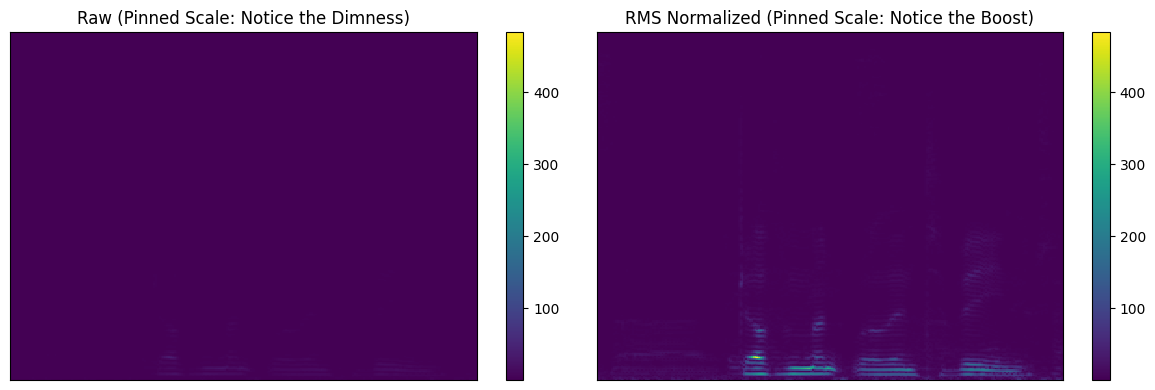

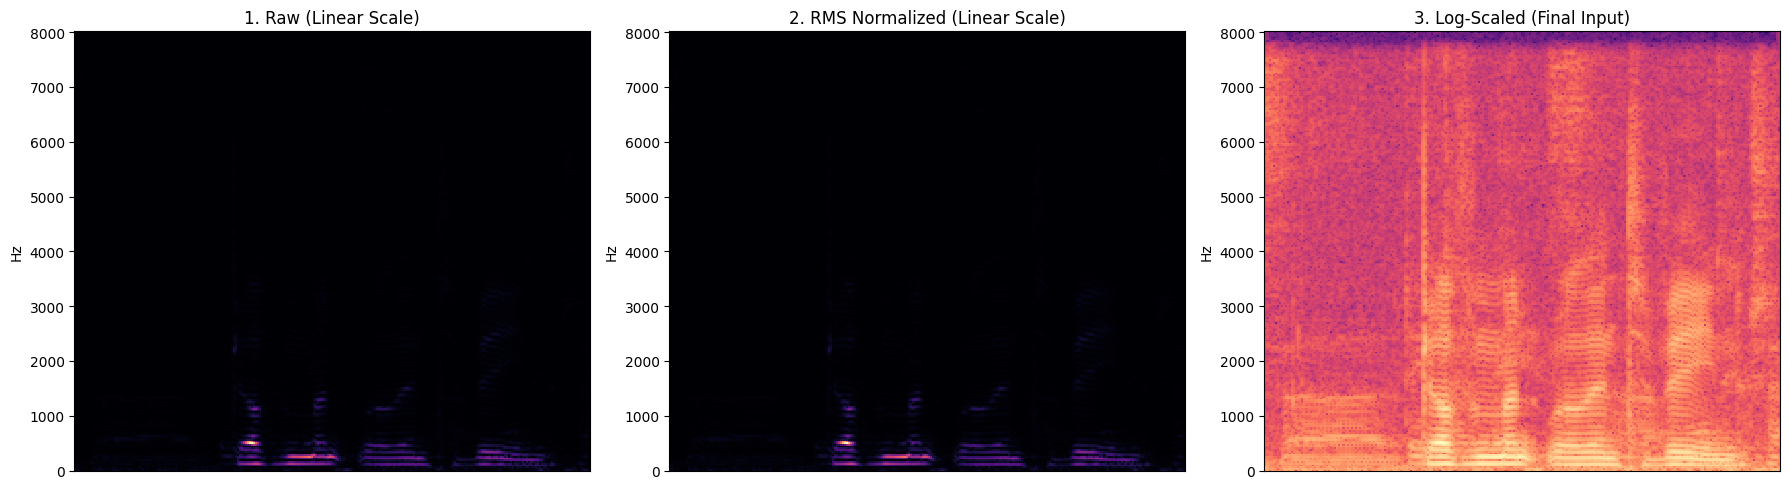

In [24]:
# --- 1. DATA PREPARATION ---
# Raw chunk (no processing)
raw_chunk = y_raw[:preprocessor.chunk_samples] 
mag_raw = np.abs(librosa.stft(raw_chunk, n_fft=preprocessor.n_fft, hop_length=preprocessor.hop_length))

# Preprocessed chunk (DC removed + RMS normalized)
# chunks[0] was already processed by your class
mag_norm = np.abs(librosa.stft(chunks[0], n_fft=preprocessor.n_fft, hop_length=preprocessor.hop_length))

# Final Product (The Log-Scaled version)
final_log_mag, _ = preprocessor.apply_stft(chunks[0])

# --- 2. VISUALIZING THE VOLUME BOOST (Pinned Scale) ---
v_max = max(np.max(mag_raw), np.max(mag_norm))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
librosa.display.specshow(mag_raw, sr=preprocessor.sr, vmax=v_max, cmap='viridis')
plt.title("Raw (Pinned Scale: Notice the Dimness)")
plt.colorbar()

plt.subplot(1, 2, 2)
librosa.display.specshow(mag_norm, sr=preprocessor.sr, vmax=v_max, cmap='viridis')
plt.title("RMS Normalized (Pinned Scale: Notice the Boost)")
plt.colorbar()
plt.tight_layout()
plt.show()

# --- 3. THE EVOLUTION (Final Comparison) ---
plt.figure(figsize=(18, 5))

# Plot 1: Raw
plt.subplot(1, 3, 1)
librosa.display.specshow(mag_raw, sr=preprocessor.sr, hop_length=preprocessor.hop_length, y_axis='hz')
plt.title("1. Raw (Linear Scale)")

# Plot 2: RMS Normalized
plt.subplot(1, 3, 2)
librosa.display.specshow(mag_norm, sr=preprocessor.sr, hop_length=preprocessor.hop_length, y_axis='hz')
plt.title("2. RMS Normalized (Linear Scale)")

# Plot 3: Final Log-Magnitude
plt.subplot(1, 3, 3)
librosa.display.specshow(final_log_mag, sr=preprocessor.sr, hop_length=preprocessor.hop_length, y_axis='hz', cmap='magma')
plt.title("3. Log-Scaled (Final Input)")

plt.tight_layout()
plt.show()

In [ ]:
# 5. Batch Processing & Merging Logic

The pipeline is designed to be memory-efficient. Instead of loading the whole dataset into RAM, it:

- Processes files in batches of 5000 chunks.  
- Saves temporary `_batch_XXXX.npz` files using `_save_batch`.  
- Merges them all at the end into a single `train_spectrograms.npz` and `test_spectrograms.npz` via `_merge_batches`.